# Max Audio Lengths (ASVspoof2019 + ITW)

This notebook computes the maximum duration in seconds for ASVspoof2019 (train/dev/eval) and ITW. It can also report max per subset if the ITW protocol includes a split column.

In [1]:
from pathlib import Path
import soundfile as sf
import pandas as pd

from data_loader import ASVspoof2019Dataset, InTheWildDataset

count: 25380
min: 0.6524375 sec
mean: 3.425824162726556 sec
max: 13.1879375 sec


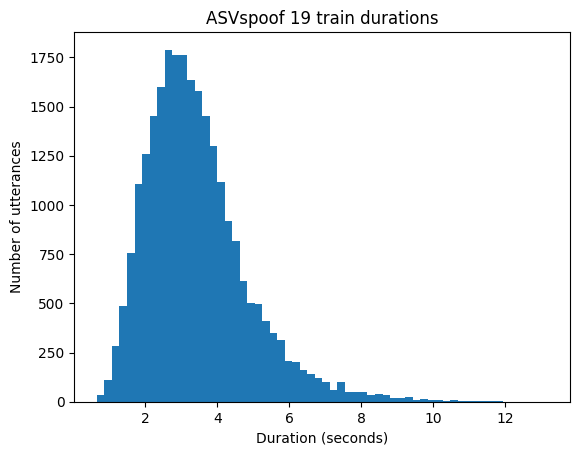

In [2]:
import glob, os
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

root = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_train/flac"
paths = glob.glob(os.path.join(root, "**", "*.flac"), recursive=True)

dur = []
for p in paths:
    info = sf.info(p)          # no full audio read
    dur.append(info.frames / info.samplerate)

dur = np.array(dur)
print("count:", len(dur))
print("min:", dur.min(), "sec")
print("mean:", dur.mean(), "sec")
print("max:", dur.max(), "sec")

plt.figure()
plt.hist(dur, bins=60)
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of utterances")
plt.title("ASVspoof 19 train durations")
plt.show()


In [2]:
# ---- Update these paths if needed ----
ASV19_TRAIN_ROOT = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_train/flac"
ASV19_TRAIN_PROTOCOL = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_train_protocol_with_speaker.txt"

ASV19_DEV_ROOT = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_dev/flac"
ASV19_DEV_PROTOCOL = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_dev_protocol_with_speaker.txt"

ASV19_EVAL_ROOT = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_eval/flac"
ASV19_EVAL_PROTOCOL = "/nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_eval_protocol_with_speaker.txt"

ITW_ROOT = "/nfs/turbo/umd-hafiz/issf_server_data/ds_wild/release_in_the_wild"
ITW_PROTOCOL = "/nfs/turbo/umd-hafiz/issf_server_data/ds_wild/protocols/meta.csv"

In [3]:
def get_duration_seconds(path: Path) -> float:
    try:
        info = sf.info(str(path))
        if info.samplerate:
            return info.frames / float(info.samplerate)
    except Exception:
        return 0.0
    return 0.0


def min_max_duration_for_paths(paths):
    max_dur = 0.0
    max_path = None
    min_dur = None
    min_path = None
    for p in paths:
        dur = get_duration_seconds(p)
        if dur <= 0:
            continue
        if dur > max_dur:
            max_dur = dur
            max_path = p
        if min_dur is None or dur < min_dur:
            min_dur = dur
            min_path = p
    return min_dur, min_path, max_dur, max_path


def print_min_max(label, min_dur, min_path, max_dur, max_path):
    if max_path is None:
        print(f"{label}: no files found")
    else:
        print(f"{label}: min={min_dur:.3f}s :: {min_path}")
        print(f"{label}: max={max_dur:.3f}s :: {max_path}")

## ASVspoof2019 (train/dev/eval)

In [4]:
asv19_train = ASVspoof2019Dataset(
    root_dir=ASV19_TRAIN_ROOT,
    protocol_file=ASV19_TRAIN_PROTOCOL,
    subset="all",
    max_duration_seconds=None,
)
asv19_dev = ASVspoof2019Dataset(
    root_dir=ASV19_DEV_ROOT,
    protocol_file=ASV19_DEV_PROTOCOL,
    subset="all",
    max_duration_seconds=None,
)
asv19_eval = ASVspoof2019Dataset(
    root_dir=ASV19_EVAL_ROOT,
    protocol_file=ASV19_EVAL_PROTOCOL,
    subset="all",
    max_duration_seconds=None,
)

train_paths = [it[0] for it in asv19_train.data]
dev_paths = [it[0] for it in asv19_dev.data]
eval_paths = [it[0] for it in asv19_eval.data]

train_min, train_min_path, train_max, train_max_path = min_max_duration_for_paths(train_paths)
dev_min, dev_min_path, dev_max, dev_max_path = min_max_duration_for_paths(dev_paths)
eval_min, eval_min_path, eval_max, eval_max_path = min_max_duration_for_paths(eval_paths)

print_min_max("ASVspoof2019 train", train_min, train_min_path, train_max, train_max_path)
print_min_max("ASVspoof2019 dev", dev_min, dev_min_path, dev_max, dev_max_path)
print_min_max("ASVspoof2019 eval", eval_min, eval_min_path, eval_max, eval_max_path)

ASVspoof2019 train: min=0.652s :: /nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_train/flac/LA_T_2303603.flac
ASVspoof2019 train: max=13.188s :: /nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_train/flac/LA_T_4111439.flac
ASVspoof2019 dev: min=0.695s :: /nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_dev/flac/LA_D_5239525.flac
ASVspoof2019 dev: max=11.594s :: /nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_dev/flac/LA_D_3698117.flac
ASVspoof2019 eval: min=0.470s :: /nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_eval/flac/LA_E_8563611.flac
ASVspoof2019 eval: max=13.026s :: /nfs/turbo/umd-hafiz/issf_server_data/AsvSpoofData_2019/train/LA/ASVspoof2019_LA_eval/flac/LA_E_4387010.flac


## ITW (overall + by split if available)

In [5]:
itw = InTheWildDataset(
    root_dir=ITW_ROOT,
    protocol_file=ITW_PROTOCOL,
    subset="all",
    max_duration_seconds=None,
)

itw_paths = [itw.audio_folder / str(row["file"]) for _, row in itw.protocol.iterrows()]
itw_min, itw_min_path, itw_max, itw_max_path = min_max_duration_for_paths(itw_paths)
print_min_max("ITW overall", itw_min, itw_min_path, itw_max, itw_max_path)

# If the protocol has a split column, show max per split.
split_col = None
for candidate in ("set", "subset", "split"):
    if candidate in itw.protocol.columns:
        split_col = candidate
        break

if split_col is not None:
    print(f"ITW by {split_col}:")
    for split_value, group in itw.protocol.groupby(split_col):
        group_paths = [itw.audio_folder / str(row["file"]) for _, row in group.iterrows()]
        min_dur, min_path, max_dur, max_path = min_max_duration_for_paths(group_paths)
        print_min_max(f"  {split_value}", min_dur, min_path, max_dur, max_path)
else:
    print("ITW: no split column found (set/subset/split).")

ITW overall: min=0.438s :: /nfs/turbo/umd-hafiz/issf_server_data/ds_wild/release_in_the_wild/19719.wav
ITW overall: max=24.991s :: /nfs/turbo/umd-hafiz/issf_server_data/ds_wild/release_in_the_wild/28237.wav
ITW: no split column found (set/subset/split).
